# BFM subroutine timings

Where does the back-and-forth method actually spend its time?  One BFM iteration is
built from four primitives.  Call counts are read off `body()` in
`uot/solvers/back_and_forth/method.py`:

| routine | calls per iteration | what it does |
|---|---|---|
| `c_transform` | 4 | quadratic c-transform of a dual potential (fast 1D Legendre per axis) |
| `poisson_solver` | 2 | Neumann Poisson solve for the H¹ ascent direction (DCT based), one per `update_potential` |
| `pushforward` | 2 | pushes a density through the map (pull + Jacobian determinant) |
| `monge_map` | 2 | Monge map in index coordinates from the gradient of ψ — needed by the pull-Jacobian pushforward variant only |

Each is timed **compiled and in isolation**, so the numbers add up to the per-iteration
cost and show which primitive dominates.  All implementations are imported from
`uot.solvers.back_and_forth` — the same code the production solver runs — except the
pull-Jacobian pushforward, which is a notebook-local variant and is defined below.

In [1]:
import sys, os

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# Pin the notebook to one accelerator *before* JAX initialises its backend.
# Override from the shell, e.g. CUDA_VISIBLE_DEVICES=1 jupyter nbconvert --execute ...
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')
sys.path.insert(0, os.path.abspath(os.path.join('../..')))

from jax import config
config.update('jax_enable_x64', True)   # slower, but precise for gradients

import time
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

print('devices:', jax.devices())

devices: [CudaDevice(id=0)]


In [2]:
# Every primitive below is the one the production BFM solver calls.
from uot.solvers.back_and_forth.method import (
    _r2_from_coords, _dctn, _idctn, neumann_kernel_nd,
)
from uot.solvers.back_and_forth.monge_map import monge_map_cic_from_psi_nd
from uot.solvers.back_and_forth.c_transform import c_transform_quadratic_fast

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

2026-09-15 18:39:37.535435: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0915 18:39:37.585103   26885 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0915 18:39:37.601275   26885 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Pull-Jacobian pushforward

Notebook-local variant: pull the density back through the inverse map with linear
interpolation, reweight by the Jacobian determinant of that map, then renormalise mass.

In [3]:
import jax
import jax.numpy as jnp
from jax import lax
from jax.scipy.ndimage import map_coordinates


def _shift_nearest(a: jnp.ndarray, axis: int, direction: int) -> jnp.ndarray:
    n = a.shape[axis]
    if direction == -1:
        head = lax.slice_in_dim(a, 1, n, axis=axis)
        tail = lax.slice_in_dim(a, n - 1, n, axis=axis)
        return jnp.concatenate([head, tail], axis=axis)
    elif direction == +1:
        head = lax.slice_in_dim(a, 0, 1, axis=axis)
        tail = lax.slice_in_dim(a, 0, n - 1, axis=axis)
        return jnp.concatenate([head, tail], axis=axis)
    else:
        raise ValueError("direction must be +1 or -1")

def _central_diff_nearest(a: jnp.ndarray, axis: int) -> jnp.ndarray:
    return 0.5 * (_shift_nearest(a, axis, -1) - _shift_nearest(a, axis, +1))

@jax.jit
def _pull_linear_1d(u: jnp.ndarray, x: jnp.ndarray) -> jnp.ndarray:
    n = u.shape[0]
    x = jnp.clip(x, 0.0, (n - 1) * 1.0)
    b = jnp.floor(x).astype(jnp.int32)
    b = jnp.clip(b, 0, n - 2)
    t = x - b.astype(x.dtype)
    return (1.0 - t) * u[b] + t * u[b + 1]

def _det2(J00, J01, J10, J11):
    return J00 * J11 - J01 * J10

def _det3(J):
    a = J[..., 0, 0]; b = J[..., 0, 1]; c = J[..., 0, 2]
    d = J[..., 1, 0]; e = J[..., 1, 1]; f = J[..., 1, 2]
    g = J[..., 2, 0]; h = J[..., 2, 1]; i = J[..., 2, 2]
    return a*(e*i - f*h) - b*(d*i - f*g) + c*(d*h - e*g)

@jax.jit
def pushforward_pull_jacobian(density: jnp.ndarray, inv_map: jnp.ndarray) -> jnp.ndarray:
    """
    density: (n1,...,nd)
    inv_map: (d,n1,...,nd) in index coordinates (inverse map S)
    """
    d = density.ndim
    if inv_map.shape[0] != d:
        raise ValueError(f"inv_map must be (d,n1,...,nd) with d={d}, got {inv_map.shape}.")

    density = density.astype(jnp.float32) if density.dtype == jnp.float64 else density
    inv_map = inv_map.astype(jnp.float32) if inv_map.dtype == jnp.float64 else inv_map

    if d == 1:
        x = inv_map[0]                       # (n,)
        pulled = _pull_linear_1d(density, x) # rho(S(y))
        Sprime = _central_diff_nearest(x, 0) # S'(y)
        rho_new = pulled * jnp.abs(Sprime)

    elif d == 2:
        pulled = map_coordinates(density, inv_map, order=1, mode="nearest")
        S0, S1 = inv_map[0], inv_map[1]
        J00 = _central_diff_nearest(S0, 0); J01 = _central_diff_nearest(S0, 1)
        J10 = _central_diff_nearest(S1, 0); J11 = _central_diff_nearest(S1, 1)
        rho_new = pulled * jnp.abs(_det2(J00, J01, J10, J11))

    elif d == 3:
        pulled = map_coordinates(density, inv_map, order=1, mode="nearest")
        S0, S1, S2 = inv_map[0], inv_map[1], inv_map[2]
        J = jnp.stack([
            jnp.stack([_central_diff_nearest(S0, 0), _central_diff_nearest(S0, 1), _central_diff_nearest(S0, 2)], axis=-1),
            jnp.stack([_central_diff_nearest(S1, 0), _central_diff_nearest(S1, 1), _central_diff_nearest(S1, 2)], axis=-1),
            jnp.stack([_central_diff_nearest(S2, 0), _central_diff_nearest(S2, 1), _central_diff_nearest(S2, 2)], axis=-1),
        ], axis=-2)
        rho_new = pulled * jnp.abs(_det3(J))

    else:
        raise ValueError("Only d=1, d=2, d=3 supported.")

    # optional mass renormalization
    m0 = jnp.sum(density)
    m1 = jnp.sum(rho_new)
    rho_new = jnp.where(m1 > 0, rho_new * (m0 / m1), rho_new)
    return rho_new

## Benchmark harness

`benchmark_compiled` compiles the function once, warms it up twice, then times
`iters` dispatches and divides.  Only the final result is blocked on, so this
measures throughput under a saturated dispatch queue rather than per-call latency.

In [4]:
def benchmark_compiled(f, *args, iters=300):
    """Mean wall-clock seconds per call of `f`, compiled and warmed up."""
    compiled = jax.jit(f).lower(*args).compile()

    for _ in range(2):                      # warm up device + caches
        y = compiled(*args)
        jax.block_until_ready(y)

    t0 = time.perf_counter()
    for _ in range(iters):
        y = compiled(*args)
    jax.block_until_ready(y)
    t1 = time.perf_counter()
    return (t1 - t0) / iters

In [5]:
from uot.problems.generators import GaussianMixtureGenerator
from uot.utils import costs, generator_helpers

BORDERS = (0.0, 1.0)
DISCRETIZATION = 'cell-centered'


def sample_problem(dim, n_points, seed=43):
    """One Gaussian pair (mu, nu) on a dim-dimensional cell-centred grid."""
    gen = GaussianMixtureGenerator(
        name='g', dim=dim, num_components=1, n_points=n_points,
        num_datasets=5, borders=BORDERS, cost_fn=costs.cost_euclid_squared,
        use_jax=False, seed=seed, measure_mode='grid',
        cell_discretization=DISCRETIZATION,
    )
    axes = generator_helpers.get_axes(
        dim=dim, borders=BORDERS, n_points=n_points,
        cell_discretization=DISCRETIZATION, use_jax=False,
    )
    problem, _ = next(iter(gen.generate_with_analytic_solution()))
    mu_m, nu_m = problem.get_marginals()
    _, mu = mu_m.to_discrete(include_zeros=True)
    _, nu = nu_m.to_discrete(include_zeros=True)
    shape = tuple(len(ax) for ax in axes)
    return (jnp.asarray(mu).reshape(shape),
            jnp.asarray(nu).reshape(shape),
            tuple(jax.device_put(jnp.asarray(ax)) for ax in axes))


def routines_for(mu, nu, coordinates):
    """The four BFM primitives, closed over one problem's grid."""
    shape = mu.shape
    hs = [c[1] - c[0] for c in coordinates]
    Ls = [hs[k] * shape[k] for k in range(len(shape))]
    kernel = neumann_kernel_nd(shape, Ls, dtype=mu.dtype)

    phi_sample = _r2_from_coords(coordinates)
    psi_sample = jnp.zeros_like(mu)
    inv_map_sample = monge_map_cic_from_psi_nd(psi_sample)
    residual_sample = nu - mu

    def poisson_solve_only(residual):
        f = residual - residual.mean()
        Uh = _dctn(f) / kernel
        Uh = Uh.at[(0,) * residual.ndim].set(0.0)
        u = _idctn(Uh)
        return u - u.mean()

    return [
        ('c_transform',    lambda phi: c_transform_quadratic_fast(phi, coordinates), (phi_sample,)),
        ('poisson_solver', poisson_solve_only,                                       (residual_sample,)),
        ('monge_map',      monge_map_cic_from_psi_nd,                                (psi_sample,)),
        ('pushforward',    pushforward_pull_jacobian,                                (mu, inv_map_sample)),
    ]

## Sweep

Time every primitive across grid resolutions in 1D and 2D, so the comparison shows
both the ranking and how each routine scales with the number of grid cells.

In [6]:
SWEEP = {
    1: (256, 512, 1024, 2048),
    2: (64, 128, 256, 512),
}
ITERS = 300

records = []
for dim, sizes in SWEEP.items():
    for n in sizes:
        mu, nu, coordinates = sample_problem(dim, n)
        n_cells = int(np.prod(mu.shape))
        for name, fn, args in routines_for(mu, nu, coordinates):
            avg_ms = 1e3 * benchmark_compiled(fn, *args, iters=ITERS)
            records.append(dict(dim=dim, n=n, n_cells=n_cells,
                                routine=name, avg_ms=avg_ms))
            print(f'dim={dim}  n={n:<5} {name:<15} {avg_ms:9.4f} ms')

df = pd.DataFrame(records)
print('\nDone. Total rows:', len(df))

dim=1  n=256   c_transform       38.4174 ms


dim=1  n=256   poisson_solver     0.1330 ms


dim=1  n=256   monge_map          0.0664 ms


dim=1  n=256   pushforward        0.0782 ms


dim=1  n=512   c_transform       76.9348 ms


...

dim=2  n=256   pushforward        0.0746 ms


dim=2  n=512   c_transform      171.9654 ms


dim=2  n=512   poisson_solver     0.3770 ms


dim=2  n=512   monge_map          0.0677 ms


dim=2  n=512   pushforward        0.0738 ms

Done. Total rows: 32


In [7]:
ROUTINES = ['c_transform', 'poisson_solver', 'monge_map', 'pushforward']

# Calls per BFM iteration, counted from body() in
# uot/solvers/back_and_forth/method.py.  monge_map counts 2 because the
# pull-Jacobian pushforward needs the map explicitly; the library's default
# adaptive pushforward folds it in.
CALLS_PER_ITER = {'c_transform': 4, 'poisson_solver': 2, 'monge_map': 2, 'pushforward': 2}

table = df.pivot_table(index=['dim', 'n', 'n_cells'], columns='routine', values='avg_ms')[ROUTINES]
weighted = table[ROUTINES] * pd.Series(CALLS_PER_ITER)
table['total_per_iter'] = weighted.sum(axis=1)
table['c_transform_share'] = weighted['c_transform'] / table['total_per_iter']
table.round(4)


routine           c_transform  poisson_solver  monge_map  pushforward  \
dim n    n_cells                                                        
1   256  256          38.4174          0.1330     0.0664       0.0782   
    512  512          76.9348          0.1324     0.0661       0.0827   
    1024 1024        153.7536          0.1347     0.0661       0.0816   
    2048 2048        307.4336          0.1330     0.0653       0.0848   
2   64   4096         21.1319          0.1829     0.0670       0.0857   
    128  16384        43.0347          0.1844     0.0675       0.1110   
    256  65536        84.7793          0.2076     0.0672       0.0746   
    512  262144      171.9654          0.3770     0.0677       0.0738   

routine           total_per_iter  c_transform_share  
dim n    n_cells                                     
1   256  256            154.2248             0.9964  
    512  512            308.3016             0.9982  
    1024 1024           615.5792             0.9991  
    2048 2048          1230.3006             0.9995  
2   64   4096            85.1988             0.9921  
    128  16384          172.8644             0.9958  
    256  65536          339.8159             0.9979  
    512  262144         688.8986             0.9985

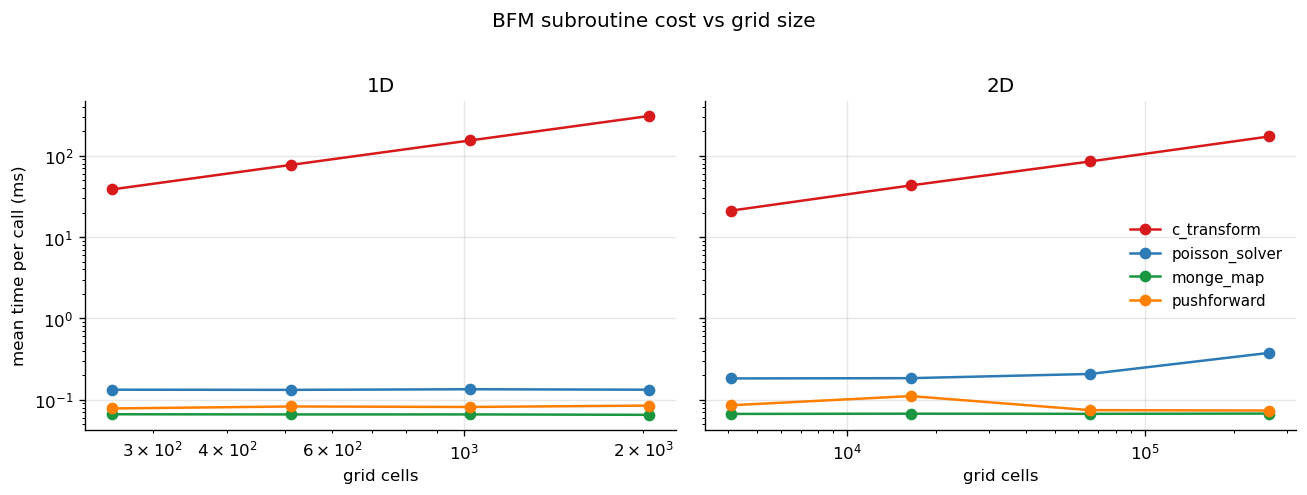

In [8]:
fig, axes_fig = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
colors = {'c_transform': '#D7191C', 'poisson_solver': '#2C7BB6',
          'monge_map': '#1A9641', 'pushforward': '#FF7F00'}

for ax, dim in zip(axes_fig, sorted(df['dim'].unique())):
    sub = df[df['dim'] == dim]
    for routine in ROUTINES:
        g = sub[sub['routine'] == routine].sort_values('n_cells')
        ax.plot(g['n_cells'], g['avg_ms'], marker='o',
                color=colors[routine], label=routine)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('grid cells')
    ax.set_title(f'{dim}D')

axes_fig[0].set_ylabel('mean time per call (ms)')
axes_fig[1].legend(frameon=False, fontsize=9)
fig.suptitle('BFM subroutine cost vs grid size', y=1.02)
fig.tight_layout()
fig.savefig('../figures/bfm_subroutine_timings.png', bbox_inches='tight')
fig.savefig('../figures/bfm_subroutine_timings.pdf', bbox_inches='tight')
plt.show()

## Summary

In [9]:
for (dim, n, n_cells), row in table.iterrows():
    ranked = row[ROUTINES].sort_values(ascending=False)
    print(f'dim={dim} n={n:<5} slowest={ranked.index[0]:<15} '
          f'{ranked.iloc[0]:9.4f} ms = {ranked.iloc[0] / ranked.iloc[-1]:8.1f}x {ranked.index[-1]}; '
          f'{100 * row["c_transform_share"]:5.1f}% of an iteration is c_transform')

dim=1 n=256   slowest=c_transform       38.4174 ms =    578.7x monge_map;  99.6% of an iteration is c_transform
dim=1 n=512   slowest=c_transform       76.9348 ms =   1164.6x monge_map;  99.8% of an iteration is c_transform
dim=1 n=1024  slowest=c_transform      153.7536 ms =   2326.2x monge_map;  99.9% of an iteration is c_transform
dim=1 n=2048  slowest=c_transform      307.4336 ms =   4706.0x monge_map; 100.0% of an iteration is c_transform
dim=2 n=64    slowest=c_transform       21.1319 ms =    315.3x monge_map;  99.2% of an iteration is c_transform
dim=2 n=128   slowest=c_transform       43.0347 ms =    638.0x monge_map;  99.6% of an iteration is c_transform
dim=2 n=256   slowest=c_transform       84.7793 ms =   1261.8x monge_map;  99.8% of an iteration is c_transform
dim=2 n=512   slowest=c_transform      171.9654 ms =   2539.7x monge_map;  99.8% of an iteration is c_transform


## Why `c_transform` dominates

The measurement is unambiguous: `c_transform` is ~99% of every BFM iteration, three
orders of magnitude above the other three primitives.

The scaling explains it.  Time grows **linearly in `n`, not in the number of grid
cells**: in 2D, going from 64² (4 096 cells) to 512² (262 144 cells) — 64× the work —
costs only ~8.6× the time, exactly the 8× growth in `n`.  Per grid cell, the
c-transform is *cheaper* in 2D than in 1D.

That is the signature of a sequential, not a compute-bound, routine.
`fast_legendre_conjugate_along_axis` builds the upper envelope of `n` lines with a
`lax.scan` over the axis, and each scan step contains its own `lax.while_loop` that
pops hull segments (`uot/solvers/back_and_forth/c_transform.py`).  The scan is a
dependency chain of length `n`, vmapped across the remaining axes — so the extra
cells of a finer 2D grid ride along for free, while the chain length sets the cost.
The GPU is idle for most of it.

The practical consequence: optimising the Poisson solve, the Monge map, or the
pushforward cannot move BFM's runtime.  Only a c-transform whose parallel depth is
better than O(n) will.